**This Notebook contains Analysis for the STA761 Research Project on University Eligibility**

In [4]:
# ============================================
# 1. IMPORTANT LIBRARIES
# ============================================
import pandas as pd
import numpy as np

# Display settings
pd.set_option('display.max_columns', None)

# ============================================
# 2. LOAD DATA
# ============================================
# Set file path
file_path = "C:/Users/Administrator/Desktop/STA 761/ResearchProject/4265563_BSc_MathStats_UWC_NWU_Eligibility.xlsx"

# Read Excel file
data = pd.read_excel(file_path, sheet_name="Candidate_summary")

# Initial inspection
data.info()
data.head()
data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106726 entries, 0 to 106725
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Candidate_id                 106726 non-null  int64         
 1   Data_Source                  106726 non-null  object        
 2   Centre_id                    106726 non-null  int64         
 3   Centre_type                  106726 non-null  object        
 4   Province                     106726 non-null  object        
 5   Exam_Date                    106726 non-null  int64         
 6   DOB                          106726 non-null  datetime64[ns]
 7   Gender                       106726 non-null  object        
 8   Race                         106726 non-null  object        
 9   NR                           106726 non-null  int64         
 10  Num_Subjects_Recorded        106726 non-null  int64         
 11  NSC_Admission_Category    

Index(['Candidate_id', 'Data_Source', 'Centre_id', 'Centre_type', 'Province',
       'Exam_Date', 'DOB', 'Gender', 'Race', 'NR', 'Num_Subjects_Recorded',
       'NSC_Admission_Category', 'Level_Obtained', 'NSC_Bachelors_Pass',
       'English_Mark', 'Second_Language_Mark', 'Mathematics_Mark',
       'Mathematical_Literacy_Mark', 'Life_Orientation_Mark',
       'Physical_Sciences_Mark', 'Life_Sciences_Mark',
       'Information_Technology_Mark', 'UWC_APS', 'UWC_Subject_Met',
       'UWC_APS_Met', 'UWC_Eligible', 'NWU_APS', 'NWU_Subjects_Counted',
       'NWU_Subject_Met', 'NWU_APS_Met', 'NWU_Eligible',
       'Eligible_UWC_or_NWU'],
      dtype='object')

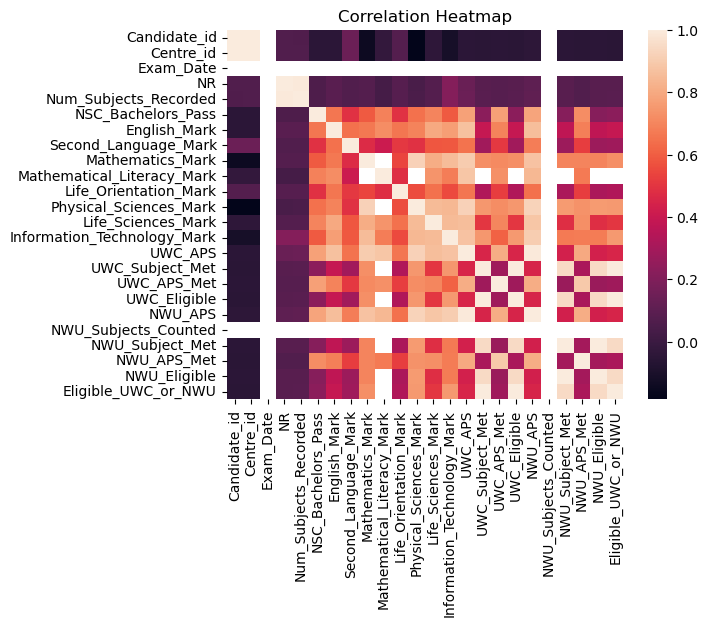

In [5]:
# correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_data = data.select_dtypes(include=np.number)
cor_matrix = numeric_data.corr()

plt.figure()
sns.heatmap(cor_matrix, annot=False)
plt.title("Correlation Heatmap")
plt.show()

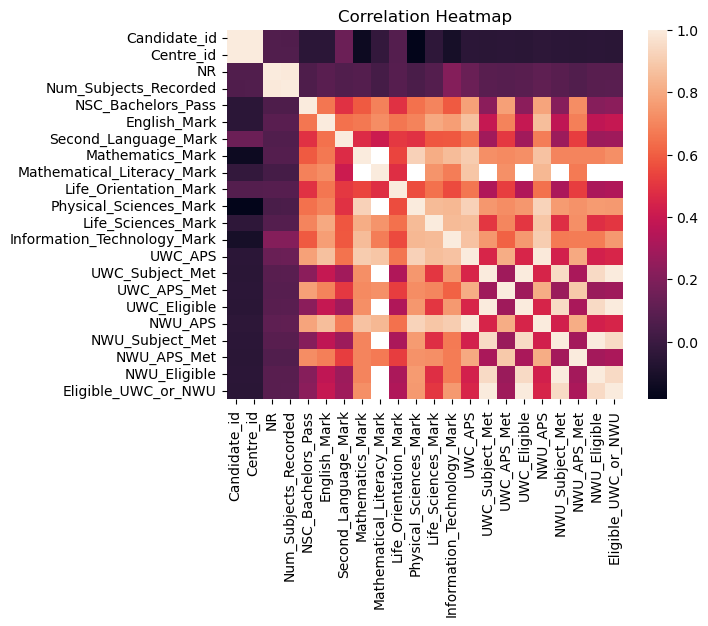

In [7]:
# remove Exam_Date, NWU_Subjects_Counted
data = data.drop(columns=['Exam_Date', 'NWU_Subjects_Counted'])

numeric_data = data.select_dtypes(include=np.number)
cor_matrix = numeric_data.corr()

plt.figure()
sns.heatmap(cor_matrix, annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# ------------------------------------------------------------
# 1. Import libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

# First 5 observations
print("\nFirst 5 observations:")
print(data.head())


First 5 observations:
   Candidate_id Data_Source  Centre_id Centre_type      Province        DOB  \
0       1000001          WC     101001      Public  Western Cape 2007-08-13   
1       1000002          WC     101001      Public  Western Cape 2005-11-03   
2       1000003          WC     101001      Public  Western Cape 2007-08-10   
3       1000004          WC     101001      Public  Western Cape 2007-04-15   
4       1000005          WC     101001      Public  Western Cape 2007-06-17   

   Gender      Race  NR  Num_Subjects_Recorded NSC_Admission_Category  \
0  Female  Coloured   7                      7              Bachelors   
1  Female  Coloured   7                      7              Bachelors   
2  Female  Coloured   7                      7              Bachelors   
3  Female  Coloured   7                      7              Bachelors   
4  Female  Coloured   7                      7              Bachelors   

           Level_Obtained  NSC_Bachelors_Pass  English_Mark  \


In [11]:
# Display column names
print("\nColumn names:")
print(data.columns.tolist())


Column names:
['Candidate_id', 'Data_Source', 'Centre_id', 'Centre_type', 'Province', 'DOB', 'Gender', 'Race', 'NR', 'Num_Subjects_Recorded', 'NSC_Admission_Category', 'Level_Obtained', 'NSC_Bachelors_Pass', 'English_Mark', 'Second_Language_Mark', 'Mathematics_Mark', 'Mathematical_Literacy_Mark', 'Life_Orientation_Mark', 'Physical_Sciences_Mark', 'Life_Sciences_Mark', 'Information_Technology_Mark', 'UWC_APS', 'UWC_Subject_Met', 'UWC_APS_Met', 'UWC_Eligible', 'NWU_APS', 'NWU_Subject_Met', 'NWU_APS_Met', 'NWU_Eligible', 'Eligible_UWC_or_NWU']


In [13]:
# Create indicator for candidates who took Mathematics Literacy
# 1-> candidate took Mathematics Literacy
# 0-> candidate did not take Mathematics Literacy
data["Math_Lit"] = (
    data["Mathematical_Literacy_Mark"].notna()
).astype(int)

print(
    data["Math_Lit"].value_counts()
)

Math_Lit
1    76842
0    29884
Name: count, dtype: int64


In [14]:
# Check the mathematics variables

print(
    data[
        [
            "Candidate_id",
            "Mathematics_Mark",
            "Mathematical_Literacy_Mark",
            "Math_Lit"
        ]
    ].head(20)
)

    Candidate_id  Mathematics_Mark  Mathematical_Literacy_Mark  Math_Lit
0        1000001               NaN                        64.0         1
1        1000002               NaN                        61.0         1
2        1000003               NaN                        74.0         1
3        1000004               NaN                        67.0         1
4        1000005               NaN                        55.0         1
5        1000006               NaN                        75.0         1
6        1000007               NaN                        67.0         1
7        1000008               NaN                        61.0         1
8        1000009               NaN                        85.0         1
9        1000010               NaN                        46.0         1
10       1000011               NaN                        54.0         1
11       1000012               NaN                        42.0         1
12       1000013               NaN                 

In [15]:
# Four possible combinations

math_status = pd.crosstab(
    data["Mathematics_Mark"].notna(),
    data["Mathematical_Literacy_Mark"].notna()
)

print(math_status)

Mathematical_Literacy_Mark  False  True 
Mathematics_Mark                        
False                        3397  76842
True                        26487      0


In [16]:
# Create eligibility variable with Mathematics Literacy rule

data["Eligibility_MathRule"] = np.where(
    data["Math_Lit"] == 1,
    0,
    data["Eligible_UWC_or_NWU"]
)

In [17]:
# Check whether any Mathematics Literacy candidates
# are still classified as eligible

check = data.groupby("Math_Lit")["Eligibility_MathRule"].value_counts()

print(check)

Math_Lit  Eligibility_MathRule
0         0                       25071
          1                        4813
1         0                       76842
Name: count, dtype: int64


In [18]:
# Number of Mathematics Literacy candidates classified as eligible

invalid = data[
    (data["Math_Lit"] == 1) &
    (data["Eligibility_MathRule"] == 1)
]

print(
    "Math Literacy candidates classified as eligible:",
    len(invalid)
)

Math Literacy candidates classified as eligible: 0


In [19]:
# Compare original and revised eligibility

comparison = pd.crosstab(
    data["Eligible_UWC_or_NWU"],
    data["Eligibility_MathRule"],
    rownames=["Original Eligibility"],
    colnames=["Eligibility with Math Literacy Rule"]
)

print(comparison)

Eligibility with Math Literacy Rule       0     1
Original Eligibility                             
0                                    101913     0
1                                         0  4813


In [21]:
# prepare variables for Logistic Regression

predictors = [
    "English_Mark",
    "Second_Language_Mark",
    "Mathematics_Mark",
    "Life_Orientation_Mark",
    "Physical_Sciences_Mark",
    "Life_Sciences_Mark",
    "Information_Technology_Mark",
    "NR",
    "Num_Subjects_Recorded"
]

In [22]:
model_variables = [
    "Eligibility_MathRule",
    "English_Mark",
    "Second_Language_Mark",
    "Mathematics_Mark",
    "Life_Orientation_Mark",
    "Physical_Sciences_Mark",
    "Life_Sciences_Mark",
    "Information_Technology_Mark",
    "NR",
    "Num_Subjects_Recorded"
]

model_data = data[model_variables].copy()

# Remove missing values for initial model
model_data = model_data.dropna()

print("Modelling observations:", len(model_data))

Modelling observations: 315


In [23]:
# Train / Test Split
from sklearn.model_selection import train_test_split

X = model_data.drop(
    columns=["Eligibility_MathRule"]
)

y = model_data["Eligibility_MathRule"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 220
Testing observations: 95


In [24]:
# Fit the Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000
    ))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic', LogisticRegression(max_iter=1000))])

In [25]:
# Predictions
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [26]:
# Evaluate the model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9157894736842105
Precision: 0.9772727272727273
Recall: 0.86
ROC-AUC: 0.9924444444444444

Confusion Matrix:
[[44  1]
 [ 7 43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92        45
           1       0.98      0.86      0.91        50

    accuracy                           0.92        95
   macro avg       0.92      0.92      0.92        95
weighted avg       0.92      0.92      0.92        95

